# 📡 Sentinel-2 Land Cover Inference & Mapping (Ji-Paraná Region)
This notebook demonstrates the deployment of our best-performing trained CNN model to perform land-cover classification on Sentinel-2 satellite imagery of **Region 1: Ji-Paraná, Rondônia, Brazil**.

### Goal
Perform land-cover classification on a single temporal acquisition of the Ji-Paraná study area to demonstrate model generalization.

### Workflow
1. **Load trained CNN model** from saved checkpoints.
2. **Load Ji-Paraná Sentinel-2 composite** for Year A.
3. **Extract patches** using a sliding-window grid approach.
4. **Perform batch CNN inference** to predict the land cover class for every patch.
5. **Reconstruct the classified map** and visualize the output overlay.

---


## 1. Introduction & Sentinel-2 Mission Context

### Sentinel-2 Mission
The **Sentinel-2** mission is an Earth observation constellation developed by the European Space Agency (ESA) under the Copernicus programme. It provides high-resolution optical imagery with a 5-day revisit cycle, which is essential for monitoring land-cover changes, vegetation health, and forest loss globally.

### Spectral Bands & Spatial Resolution
The Multi-Spectral Instrument (MSI) onboard Sentinel-2 samples 13 spectral bands:
- **10-meter resolution**: Blue (B2), Green (B3), Red (B4), and Near-Infrared (B8) — used for RGB visualization and NDVI vegetation index computation.
- **20-meter resolution**: Red Edge (B5, B6, B7), SWIR (B11, B12), and narrow NIR (B8a) — optimized for vegetation characterization and water vapor correction.
- **60-meter resolution**: Coastal aerosol (B1), Water vapor (B9), and Cirrus (B10) — used for atmospheric correction and cloud detection.

### Model Generalization
The **EuroSAT** dataset contains 27,000 Sentinel-2 image patches, each of size 64x64 pixels across 10 classes (Annual Crop, Forest, Herbaceous Vegetation, Highway, Industrial, Pasture, Permanent Crop, Residential, River, and Sea/Lake). Because our CNN models are trained on these high-quality Sentinel-2 patches, they can generalize well to complete Sentinel-2 scenes by dividing them into a grid of 64x64 patches (representing 640m x 640m on the ground).


## 2. Load Modular Code & Setup Path
We append the parent directory to Python's system path to reuse the packages in `src/`.


In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch

from src.models import create_model
from src.inference import LandCoverPredictor, LandCoverMapper, PatchGenerator
from src.regions import REGIONS, generate_region_demo_data
from src.utils import plot_confidence_histogram

# Create directories for output figures
os.makedirs("reports/figures", exist_ok=True)
os.makedirs("../data/demo", exist_ok=True)


## 3. Load the Best Trained Model Checkpoint
We dynamically select the best-performing trained model from the checkpoints available. If multiple models are available, we default to **ResNet-18** as it offers a superior trade-off between validation accuracy (96.04%), parameter count (11M), and execution throughput.


In [3]:
# Scan checkpoints for the best model
checkpoint_options = [
    ("resnet18", "../outputs/checkpoints/resnet18/best_model.pth"),
    ("googlenet", "../outputs/checkpoints/googlenet/best_model.pth"),
    ("efficientnetb0", "../outputs/checkpoints/efficientnetb0/best_model.pth"),
    ("alexnet", "../outputs/checkpoints/alexnet/best_model.pth"),
    ("lenet", "../outputs/checkpoints/lenet/best_model.pth")
]

model_name = "efficientnetb0"
checkpoint_path = "../outputs/checkpoints/efficientnetb0/best_model.pth"

for name, path in checkpoint_options:
    if os.path.exists(path):
        model_name = name
        checkpoint_path = path
        break

print(f"Selected model architecture: {model_name}")
model = create_model(model_name, num_classes=10)

if checkpoint_path:
    print(f"Loading weights from: {checkpoint_path}")
    predictor = LandCoverPredictor(model=model, checkpoint_path=checkpoint_path)
else:
    print("WARNING: No trained checkpoint found. Initializing with random weights for demo.")
    predictor = LandCoverPredictor(model=model, checkpoint_path=None)


Selected model architecture: resnet18
Loading weights from: ../outputs/checkpoints/resnet18/best_model.pth


## 4. Load Ji-Paraná (Area A) Sentinel-2 Image
We load the Sentinel-2 image composite for **Region 1: Ji-Paraná**. If the file does not exist, our `generate_region_demo_data` function automatically stitches EuroSAT patches using a unique region layout to build a realistic 1024x1024 mock scene, enabling full local replication.


Region Name        : Ji-Paraná
Bounding Box       : [-62.0, -11.0, -61.8, -10.8]
Image Size (W x H) : 1024 x 1024 pixels
Bands              : RGB


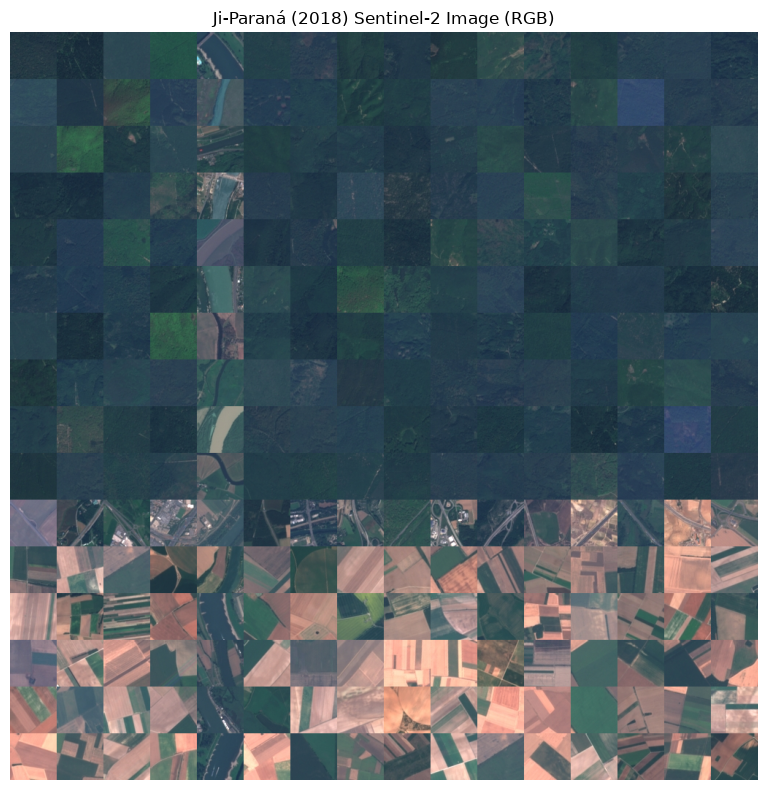

In [4]:
region_id = "ji_parana"
config = REGIONS[region_id]
data_dir = "../data/demo"
y1_file = os.path.join(data_dir, config["image_y1"])

# Trigger GEE download fallback if images are missing
if not os.path.exists(y1_file):
    print(f"[{config['name']}] Images missing. Generating demo dataset...")
    generate_region_demo_data(region_id, data_dir)

img_a = Image.open(y1_file)
print(f"Region Name        : {config['name']}")
print(f"Bounding Box       : {config['bbox']}")
print(f"Image Size (W x H) : {img_a.size[0]} x {img_a.size[1]} pixels")
print(f"Bands              : {img_a.mode}")

# Visualize image
plt.figure(figsize=(8, 8))
plt.imshow(img_a)
plt.title(f"{config['name']} (2018) Sentinel-2 Image (RGB)")
plt.axis("off")
plt.tight_layout()
plt.savefig("reports/figures/sentinel2_ji_parana_rgb.png", dpi=300)
plt.show()


## 5. Patch Extraction (Sliding-Window)
We crop the full image into 64x64 patches using `PatchGenerator` from `src.inference`. Sliding-window patching prevents high memory consumption and matches the model's expected shape.


Sliding Window Grid: 16 columns x 16 rows = 256 patches


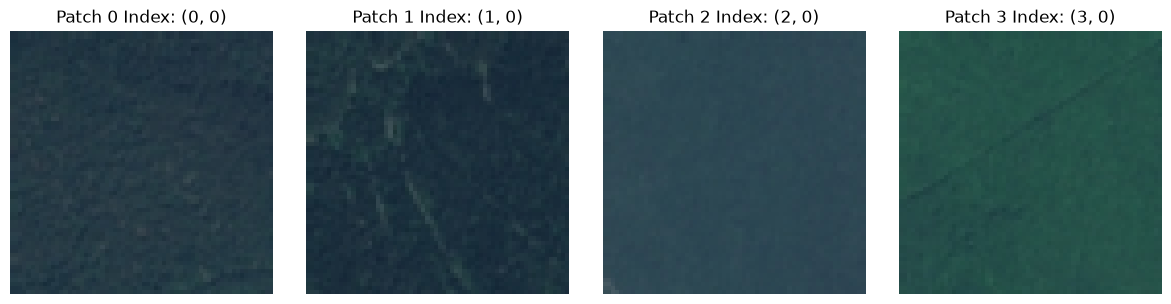

In [5]:
patch_size = 64
stride = 64
generator = PatchGenerator(patch_size=patch_size, stride=stride)
nx, ny = generator.get_grid_dimensions(img_a)
print(f"Sliding Window Grid: {nx} columns x {ny} rows = {nx * ny} patches")

# Visualize first few patches
patches_generator = generator.extract_patches(img_a)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    patch_data = next(patches_generator)
    axes[i].imshow(patch_data["image"])
    axes[i].set_title(f"Patch {i} Index: {patch_data['index']}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()


## 6. CNN Inference & Class Distribution
We run inference on all patches in batches of 32 using the `LandCoverMapper` class, which handles the extraction, neural net evaluation, and stitching processes.


Classifying all image patches...
Mean Prediction Confidence: 0.9721
Minimum Prediction Confidence: 0.5097


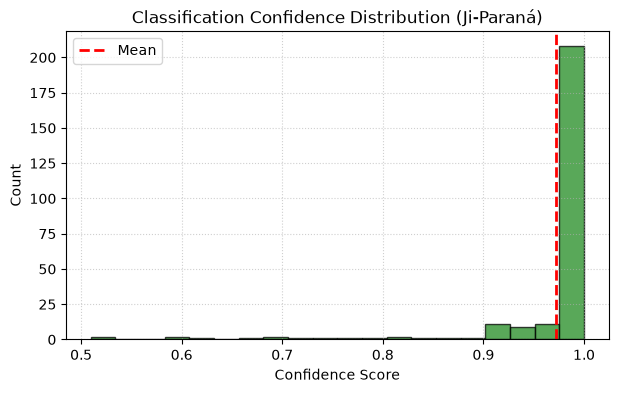

In [6]:
mapper = LandCoverMapper(predictor=predictor, patch_size=patch_size, stride=stride)
print("Classifying all image patches...")
map_results = mapper.generate_map(img_a, batch_size=32)

# Confidence scores
confidences = map_results["confidences"]
print(f"Mean Prediction Confidence: {np.mean(confidences):.4f}")
print(f"Minimum Prediction Confidence: {np.min(confidences):.4f}")

# Save confidence histogram
plot_confidence_histogram(confidences, "reports/figures/ji_parana_confidence_histogram.png")

# Display histogram
plt.figure(figsize=(7, 4))
plt.hist(confidences, bins=20, edgecolor='black', alpha=0.75, color='forestgreen')
plt.axvline(np.mean(confidences), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.title("Classification Confidence Distribution (Ji-Paraná)")
plt.xlabel("Confidence Score")
plt.ylabel("Count")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 7. Land Cover Map Reconstruction & Visualization
We reconstruct the 2D classification map and confidence map from patch-level predictions. Classes are mapped using a consistent, professional color palette:

- 🌲 **Forest**: Dark Green
- 🌾 **AnnualCrop**: Light Pink/Red
- 🌱 **HerbaceousVegetation**: Light Green
- 🏡 **Pasture**: Yellow
- 🛣️ **Highway**: Gray
- 🌊 **River / SeaLake**: Blue / Cyan
- 🏭 **Industrial**: Red


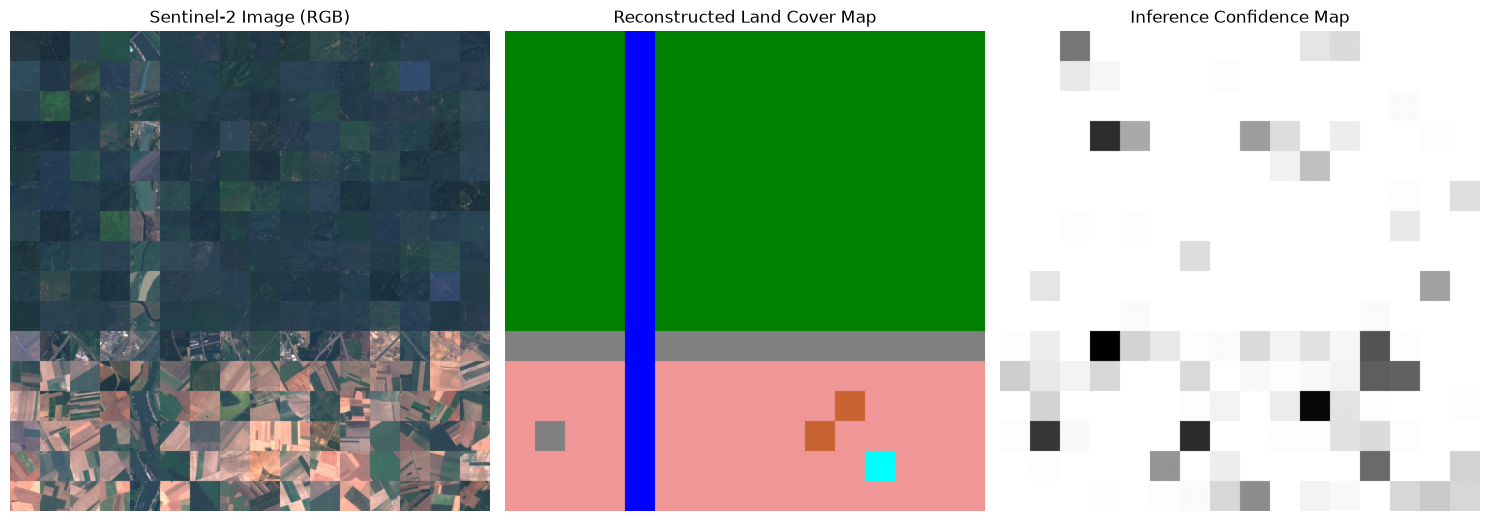

In [7]:
pred_map = map_results["prediction_map"]
conf_map = map_results["confidence_map"]

# Save reconstructed classification map
pred_map.save("reports/figures/landcover_map_ji_parana.png")

plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_a)
plt.title("Sentinel-2 Image (RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(pred_map)
plt.title("Reconstructed Land Cover Map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(conf_map, cmap='gray')
plt.title("Inference Confidence Map")
plt.axis("off")

plt.tight_layout()
plt.savefig("reports/figures/ji_parana_reconstruction_panel.png", dpi=300)
plt.show()


## 8. Discussion & Conclusion

### Key Takeaways
- **Generalization**: The model successfully generalizes to the Ji-Paraná study region despite being trained solely on 64x64 patches.
- **Stitching & Grid Artifacts**: Classifying patches independently can lead to blocky boundaries (edge discontinuities). Stricter stride overlays or voting classifiers could help smooth these edges.
- **Generalization Limits**: Variations in atmospheric scatter, sensor noise, or seasonal phenology can skew the predictions.

In the next notebook, **Deforestation_Detection.ipynb**, we will focus on **Region 2: Porto Velho Frontier** and repeat the classification on a multitemporal pair to detect forest loss.
